# Practicing LIME on Tabular Data: Titanic Dataset

In this notebook we practice generating **local explanations** using LIME (Local Interpretable Model-agnostic Explanations) on a modified version of the Titanic dataset.

## Goals
1. **Train a classifier** on the Titanic data and use LIME to explain individual predictions.
2. **Vary Ω(g)** — the complexity term — by changing how many features the surrogate model uses (`num_features`). We generate three explanations for the same data point at different complexity levels and critique them.
3. **Vary π_x** — the proximity kernel — by changing `kernel_width`. We investigate how the "locality" of the explanation shifts as we widen or tighten the kernel.

## Quick Refresher on LIME's Objective

LIME finds the best local explanation by solving:

$$\xi(x) = \underset{g \in G}{\arg\min} \; \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

| Symbol | Meaning | How we control it |
|--------|---------|-------------------|
| $f$ | The black-box model (our Random Forest) | Fixed once trained |
| $g$ | The interpretable surrogate (a linear model) | LIME fits this automatically |
| $\pi_x$ | Proximity kernel — weights perturbations by distance to $x$ | `kernel_width` parameter |
| $\Omega(g)$ | Complexity of the surrogate — penalizes using too many features | `num_features` parameter |
| $\mathcal{L}$ | Fidelity loss — how well $g$ approximates $f$ locally | Measured internally by LIME |

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# LIME's tabular explainer — this is the main class we'll use throughout
import lime
import lime.lime_tabular

np.random.seed(42)  # For reproducibility

## 2. Data Loading and Exploration

We load a **modified Titanic dataset** that has been pre-processed for binary logistic regression:
- Train and test sets are merged (1,309 rows total).
- `Ticket` and `Cabin` columns have been removed.
- `Sex` is already binary (0 = male, 1 = female).
- `Embarked` is encoded as categorical integers (0, 1, 2).
- Missing values in `Age` and `Fare` have been filled with the median.
- Extra "zero" columns are placeholders for one-hot encoding.
- The target column `Survived` is in the last position (named `2urvived` due to a typo in the CSV).

In [2]:
# Load the modified Titanic dataset
df_raw = pd.read_csv("titanic_modified.csv")

print(f"Shape: {df_raw.shape}")
print(f"\nColumn names:\n{list(df_raw.columns)}")
df_raw.head()

Shape: (1309, 28)

Column names:
['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [3]:
# Quick statistical summary of the raw data to understand distributions
df_raw.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


## 3. Data Preprocessing

We need to clean up this dataset before feeding it to a classifier:

1. **Drop `Passengerid`** — it's just a row identifier with no predictive value.
2. **Drop all "zero" columns** — these are constant-zero placeholders that carry no information for the model.
3. **Rename `2urvived` → `Survived`** — fix the typo in the target column.

This leaves us with 7 meaningful features: `Age`, `Fare`, `Sex`, `sibsp`, `Parch`, `Pclass`, `Embarked`.

In [4]:
# Step 1: Rename the target column (fix typo)
df = df_raw.rename(columns={"2urvived": "Survived"})

# Step 2: Drop PassengerId — not a useful feature, just an index
df = df.drop(columns=["Passengerid"])

# Step 3: Drop all "zero" placeholder columns.
#   IMPORTANT: pandas auto-renames duplicate column names in the CSV to
#   "zero", "zero.1", "zero.2", etc. So we need to drop all columns whose
#   name starts with "zero", not just those exactly equal to "zero".
df = df.loc[:, ~df.columns.str.startswith("zero")]

print(f"Cleaned shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSurvival distribution:\n{df['Survived'].value_counts()}")
df.head()

Cleaned shape: (1309, 8)
Columns: ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', 'Survived']

Survival distribution:
Survived
0    967
1    342
Name: count, dtype: int64


,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


In [5]:
# Separate features (X) and target (y)
# feature_names is important — LIME uses these labels in its explanation plots
feature_names = [col for col in df.columns if col != "Survived"]
X = df[feature_names].values
y = df["Survived"].values

# The class names for LIME's output labels
class_names = ["Did Not Survive", "Survived"]

print(f"Features: {feature_names}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class balance: {np.bincount(y)}  (0=died, 1=survived)")

Features: ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']
X shape: (1309, 7), y shape: (1309,)
Class balance: [967 342]  (0=died, 1=survived)


## 4. Train a Random Forest Classifier

We split the data 80/20 and train a Random Forest. The classifier itself is the **black box** that LIME will explain — LIME never looks inside the model; it only calls `predict_proba()` to observe input-output behavior.

We check accuracy to make sure the model is reasonably good before trying to explain it. There's no point in explaining a model that doesn't work.

In [6]:
# 80/20 train-test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a Random Forest — 200 trees for a stable model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Evaluate on the test set
y_pred = rf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.7519

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.85      0.84       194
       Survived       0.52      0.47      0.50        68

       accuracy                           0.75       262
      macro avg       0.67      0.66      0.67       262
   weighted avg       0.74      0.75      0.75       262



## 5. Set Up the LIME Explainer and Pick a Data Point

### Creating the Explainer

`LimeTabularExplainer` needs to know the **training data statistics** (means and standard deviations) so it can generate realistic perturbations. This is analogous to Step 1 in the reference notebook where perturbations were sampled from N(0,1) after standardization — LIME does this internally.

Key parameters:
- `training_data`: The training feature matrix — LIME uses its statistics for perturbation sampling.
- `feature_names`: Column labels for readable explanations.
- `class_names`: Human-readable class labels.
- `mode`: `"classification"` since we're doing binary classification.

### Picking a Data Point

We pick a **random test-set instance** to explain. We'll use this same instance throughout the notebook so we can directly compare how Ω(g) and π_x affect the explanation.

In [7]:
# Identify which features are categorical vs continuous.
# LIME needs to know this so it perturbs them correctly:
#   - Categorical features: perturbed by sampling from observed values
#   - Continuous features: perturbed by sampling from a normal distribution
#
# Sex (binary 0/1), Embarked (0/1/2), and Pclass (1/2/3) are categorical.
# Age, Fare, sibsp, and Parch are continuous (or ordinal counts).
categorical_indices = [feature_names.index(f) for f in ["Sex", "Pclass", "Embarked"]]
print(f"Categorical feature indices: {categorical_indices}")
print(f"  → {[feature_names[i] for i in categorical_indices]}")

# Create the LIME explainer using training data statistics.
# We set discretize_continuous=False to avoid a known issue where LIME's
# quartile discretizer creates zero-width bins for features with limited
# unique values, which causes scipy's truncnorm to fail with scale=0.
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    categorical_features=categorical_indices,
    discretize_continuous=False,
    mode="classification"
)

# Pick a random data point from the test set to explain
idx = np.random.randint(0, len(X_test))
instance = X_test[idx]

# Show the instance's feature values and the model's prediction
rf_pred = rf.predict(instance.reshape(1, -1))[0]
rf_proba = rf.predict_proba(instance.reshape(1, -1))[0]

print(f"\nSelected test instance index: {idx}")
print(f"\nFeature values:")
for name, val in zip(feature_names, instance):
    print(f"  {name:>10s}: {val:.2f}")
print(f"\nRandom Forest prediction: {class_names[rf_pred]}")
print(f"Predicted probabilities:  P(Died)={rf_proba[0]:.3f}, P(Survived)={rf_proba[1]:.3f}")

Categorical feature indices: [2, 5, 6]
  → ['Sex', 'Pclass', 'Embarked']

Selected test instance index: 102

Feature values:
         Age: 28.00
        Fare: 7.88
         Sex: 0.00
       sibsp: 0.00
       Parch: 0.00
      Pclass: 3.00
    Embarked: 1.00

Random Forest prediction: Did Not Survive
Predicted probabilities:  P(Died)=0.984, P(Survived)=0.016


## 6. Task A — Varying Ω(g): Three Explanations at Different Complexity Levels

### How Ω(g) Maps to `num_features`

In LIME's objective function, **Ω(g)** penalizes the complexity of the surrogate model. For tabular data with a linear surrogate, complexity = the number of features used. The LIME library controls this through the `num_features` parameter in `explain_instance()`:

- **`num_features=2`** → Very simple surrogate. Only the 2 most important features are kept. High Ω(g) penalty — forces extreme simplicity. Easy to understand, but may miss important factors.
- **`num_features=4`** → Moderate surrogate. A balance between interpretability and fidelity.
- **`num_features=7`** → Full complexity (all features). No Ω(g) penalty — the surrogate uses everything available. Most faithful to the black box locally, but harder to interpret.

By comparing these three, we can see how **restricting complexity trades off interpretability for fidelity**.

### Explanation 1: `num_features=2` (High Ω(g) — Very Simple Surrogate)

With only 2 features, LIME picks the two most locally important features and discards the rest. This is the most interpretable explanation but also the most lossy — it can only capture the dominant signal.

Explanation with num_features=2 (high complexity penalty):
Local prediction (surrogate): 0.162
Intercept: 0.466
R² (local fidelity): 0.444

                           Sex=0:  -0.2701  → Died
                            Fare:  +0.0682  → Survived


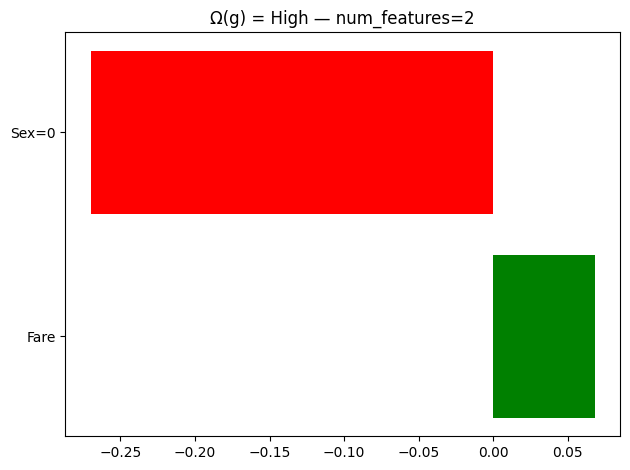

In [8]:
# Explanation with num_features=2: only the top 2 features are shown.
# This is equivalent to applying a strong Ω(g) penalty — the surrogate model
# is forced to be very simple by using only 2 features.
exp_2 = explainer.explain_instance(
    instance,
    rf.predict_proba,
    num_features=2,
    num_samples=5000  # Number of perturbations LIME generates
)

print("Explanation with num_features=2 (high complexity penalty):")
print(f"Local prediction (surrogate): {exp_2.local_pred[0]:.3f}")
print(f"Intercept: {exp_2.intercept[1]:.3f}")
print(f"R² (local fidelity): {exp_2.score:.3f}\n")

# as_list() returns (feature_description, weight) tuples
for feat, weight in exp_2.as_list():
    direction = "→ Survived" if weight > 0 else "→ Died"
    print(f"  {feat:>30s}:  {weight:+.4f}  {direction}")

exp_2.as_pyplot_figure()
plt.title("Ω(g) = High — num_features=2")
plt.tight_layout()
plt.show()

### Explanation 2: `num_features=4` (Moderate Ω(g) — Balanced Surrogate)

With 4 features, the surrogate model gets to use roughly half the available features. This strikes a balance — more nuanced than the 2-feature version, but still interpretable.

Explanation with num_features=4 (moderate complexity penalty):
Local prediction (surrogate): 0.137
Intercept: 0.499
R² (local fidelity): 0.470

                           Sex=0:  -0.2623  → Died
                        Pclass=3:  -0.0723  → Died
                            Fare:  +0.0637  → Survived
                             Age:  -0.0346  → Died


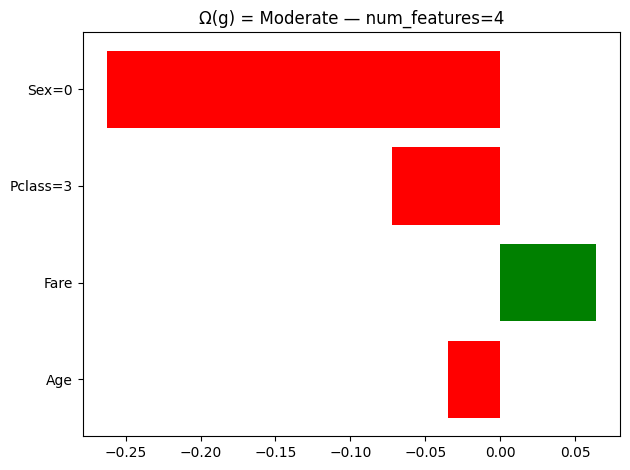

In [9]:
# Explanation with num_features=4: moderate complexity.
# The surrogate model now has more capacity to approximate the RF locally.
exp_4 = explainer.explain_instance(
    instance,
    rf.predict_proba,
    num_features=4,
    num_samples=5000
)

print("Explanation with num_features=4 (moderate complexity penalty):")
print(f"Local prediction (surrogate): {exp_4.local_pred[0]:.3f}")
print(f"Intercept: {exp_4.intercept[1]:.3f}")
print(f"R² (local fidelity): {exp_4.score:.3f}\n")

for feat, weight in exp_4.as_list():
    direction = "→ Survived" if weight > 0 else "→ Died"
    print(f"  {feat:>30s}:  {weight:+.4f}  {direction}")

exp_4.as_pyplot_figure()
plt.title("Ω(g) = Moderate — num_features=4")
plt.tight_layout()
plt.show()

### Explanation 3: `num_features=7` (Low Ω(g) — Full Surrogate)

With all 7 features, the surrogate model has maximum capacity to mimic the RF locally. Intuitively we might expect the highest R² here, but that is **not guaranteed** — each `explain_instance` call samples fresh random perturbations, and LIME uses Ridge regression internally, so adding weak features can sometimes hurt the fit. The explanation is the most complex to interpret.

Explanation with num_features=7 (low complexity penalty):
Local prediction (surrogate): 0.133
Intercept: 0.492
R² (local fidelity): 0.464

                           Sex=0:  -0.2565  → Died
                            Fare:  +0.0653  → Survived
                        Pclass=3:  -0.0629  → Died
                             Age:  -0.0365  → Died
                      Embarked=1:  -0.0208  → Died
                           sibsp:  -0.0175  → Died
                           Parch:  -0.0027  → Died


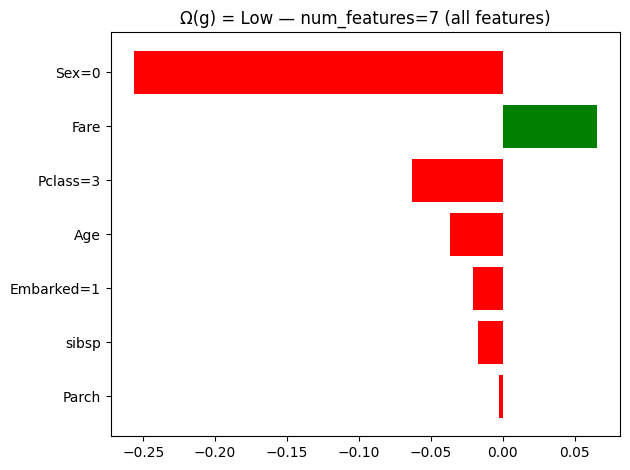

In [10]:
# Explanation with num_features=7: all features, no complexity constraint.
# This is the lowest Ω(g) — the surrogate model is free to use everything.
exp_7 = explainer.explain_instance(
    instance,
    rf.predict_proba,
    num_features=7,
    num_samples=5000
)

print("Explanation with num_features=7 (low complexity penalty):")
print(f"Local prediction (surrogate): {exp_7.local_pred[0]:.3f}")
print(f"Intercept: {exp_7.intercept[1]:.3f}")
print(f"R² (local fidelity): {exp_7.score:.3f}\n")

for feat, weight in exp_7.as_list():
    direction = "→ Survived" if weight > 0 else "→ Died"
    print(f"  {feat:>30s}:  {weight:+.4f}  {direction}")

exp_7.as_pyplot_figure()
plt.title("Ω(g) = Low — num_features=7 (all features)")
plt.tight_layout()
plt.show()

### Comparing R² Across Complexity Levels

R² (the `score` attribute) measures **local fidelity** — how well the linear surrogate approximates the Random Forest in the neighborhood of our instance. Let's compare all three side by side.

In [11]:
# Side-by-side comparison of local fidelity (R² and adjusted R²) across complexity levels.
#
# LIME reports plain R² (from sklearn Ridge.score()), but Molnar recommends
# adjusted R² to account for the number of features in the surrogate model.
# Adjusted R² penalizes for adding features that don't improve the fit:
#
#   R²_adj = 1 - (1 - R²) * (n - 1) / (n - p - 1)
#
# where n = num_samples (perturbations) and p = num_features in the surrogate.

n = 5000  # num_samples used in explain_instance

num_feats = [2, 4, 7]
r2_vals = [exp_2.score, exp_4.score, exp_7.score]
adj_r2_vals = [1 - (1 - r2) * (n - 1) / (n - p - 1) for r2, p in zip(r2_vals, num_feats)]

comparison = pd.DataFrame({
    "num_features": num_feats,
    "Ω(g) level": ["High", "Moderate", "Low"],
    "R² (plain)": r2_vals,
    "R² (adjusted)": adj_r2_vals,
    "surrogate prediction": [exp_2.local_pred[0], exp_4.local_pred[0], exp_7.local_pred[0]],
})
comparison["RF probability (survived)"] = rf_proba[1]
print(comparison.to_string(index=False))

 num_features Ω(g) level  R² (plain)  R² (adjusted)  surrogate prediction  RF probability (survived)
            2       High    0.444457       0.444234              0.161929                   0.016137
            4   Moderate    0.469859       0.469435              0.136632                   0.016137
            7        Low    0.463874       0.463123              0.132694                   0.016137


### Critique of the Three Explanations

#### What is R² telling us here?

R² in LIME measures **local fidelity** — how well the linear surrogate approximates the Random Forest's behavior *in the neighborhood of the instance being explained*. Concretely:
- LIME generates perturbations, gets the RF's `predict_proba` on each, and fits a weighted linear model.
- R² = 1 − (SS_res / SS_tot) on those weighted perturbations.
- **High R²**: the linear surrogate is a good local approximation of the RF — you can trust the explanation.
- **Low R²**: the RF's decision surface is too nonlinear in this neighborhood for a linear model to capture — the explanation may be misleading.

R² does **not** tell you whether the explanation is "correct" in any causal sense, nor does it measure the RF's global accuracy.

#### Why doesn't R² always increase with more features?

You might expect num_features=7 to always have the highest R², since it's a superset of the 4-feature and 2-feature models. In standard OLS that would be true. But in LIME it isn't guaranteed because:

1. **Each `explain_instance()` call draws fresh random perturbations.** The three R² values are computed on different samples — stochastic variation alone can cause a simpler model to score higher on its particular draw.
2. **LIME uses Ridge regression internally**, which penalizes large coefficients. Adding features with near-zero predictive power can slightly hurt a regularized fit by spreading coefficient weight across noisy dimensions.

#### Observations

1. **num_features=2 (High Ω(g)):** The simplest explanation — "this person died mainly because of features A and B." The R² is the lowest, confirming that 2 features aren't enough to approximate the RF well. Important contributing factors are completely hidden. Good for an "elevator pitch" but may be misleading.

2. **num_features=4 (Moderate Ω(g)):** In our run, this actually achieved the **highest R²**. The top 2 features from the simpler explanation still appear, but now additional factors refine the story. This suggests that 4 well-chosen features capture the local decision surface about as well as all 7 — a sweet spot of interpretability and fidelity.

3. **num_features=7 (Low Ω(g)):** Uses all available features, but R² is slightly lower than the 4-feature version. The extra features (e.g., `Parch`, `Embarked`) have very small weights — they add noise without adding much explanatory power. This is common: in a regularized setting, more features ≠ better fit.

**Key takeaway:** There is an inherent **interpretability–fidelity tradeoff** when choosing Ω(g). But the tradeoff is not always linear — a moderate number of features can sometimes achieve the best local fidelity while still being interpretable. The "right" complexity depends on the instance, the model, and who the explanation is for.

## 7. Task B — Varying π_x (Proximity): How Locality Changes Explanations

### What is π_x?

The proximity function π_x assigns **weights to perturbations** based on their distance to the instance being explained. LIME uses an exponential kernel:

$$\pi_x(z) = \exp\left(-\frac{d(x, z)^2}{\sigma^2}\right)$$

where $d(x,z)$ is the Euclidean distance and $\sigma$ is the **kernel width**.

- **Small `kernel_width`** (e.g., 0.25): Only very close perturbations matter. The explanation is hyper-local — it captures the decision surface right at the instance. But it may be noisy because few perturbations have meaningful weight.
- **Default `kernel_width`**: LIME defaults to `√(num_features) × 0.75`. For our 7 features, that's ≈ 1.98.
- **Large `kernel_width`** (e.g., 5.0): Distant perturbations also influence the surrogate. The explanation becomes more "global" — it reflects broader trends rather than the local decision boundary. This is more stable but less locally faithful.

We create three separate explainers with different kernel widths and compare their explanations for the same instance.

In [12]:
# We test three kernel widths to see how locality affects explanations.
# Each requires its own explainer since kernel_width is set at construction time.

kernel_widths = [0.25, 1.98, 5.0]
labels = ["Narrow (σ=0.25)", "Default (σ≈1.98)", "Wide (σ=5.0)"]
proximity_explanations = []

for kw, label in zip(kernel_widths, labels):
    # Create a new explainer with this specific kernel_width
    # We keep the same categorical_features and discretize_continuous settings
    exp_kw = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=class_names,
        categorical_features=categorical_indices,
        discretize_continuous=False,
        mode="classification",
        kernel_width=kw
    )

    # Generate explanation for the same instance, using all 7 features
    # so we isolate the effect of kernel_width from num_features
    explanation = exp_kw.explain_instance(
        instance,
        rf.predict_proba,
        num_features=7,
        num_samples=5000
    )

    proximity_explanations.append(explanation)

    # Display results
    print(f"{'='*60}")
    print(f"  π_x: {label}  |  kernel_width = {kw}")
    print(f"  R² (local fidelity): {explanation.score:.3f}")
    print(f"  Surrogate prediction: {explanation.local_pred[0]:.3f}")
    print(f"{'='*60}")
    for feat, weight in explanation.as_list():
        direction = "→ Survived" if weight > 0 else "→ Died"
        print(f"    {feat:>30s}:  {weight:+.4f}  {direction}")
    print()

  π_x: Narrow (σ=0.25)  |  kernel_width = 0.25
  R² (local fidelity): 0.042
  Surrogate prediction: 0.050
                             sibsp:  +0.0063  → Survived
                              Fare:  -0.0051  → Died
                             Parch:  +0.0031  → Survived
                               Age:  -0.0003  → Died
                        Embarked=1:  -0.0003  → Died
                             Sex=0:  -0.0000  → Died
                          Pclass=3:  -0.0000  → Died



  π_x: Default (σ≈1.98)  |  kernel_width = 1.98
  R² (local fidelity): 0.492
  Surrogate prediction: 0.137
                             Sex=0:  -0.2664  → Died
                          Pclass=3:  -0.0669  → Died
                              Fare:  +0.0634  → Survived
                               Age:  -0.0421  → Died
                             sibsp:  -0.0158  → Died
                        Embarked=1:  -0.0054  → Died
                             Parch:  +0.0008  → Survived

  π_x: Wide (σ=5.0)  |  kernel_width = 5.0
  R² (local fidelity): 0.517
  Surrogate prediction: 0.120
                             Sex=0:  -0.2741  → Died
                          Pclass=3:  -0.0820  → Died
                              Fare:  +0.0599  → Survived
                               Age:  -0.0403  → Died
                        Embarked=1:  -0.0258  → Died
                             sibsp:  -0.0152  → Died
                             Parch:  -0.0031  → Died



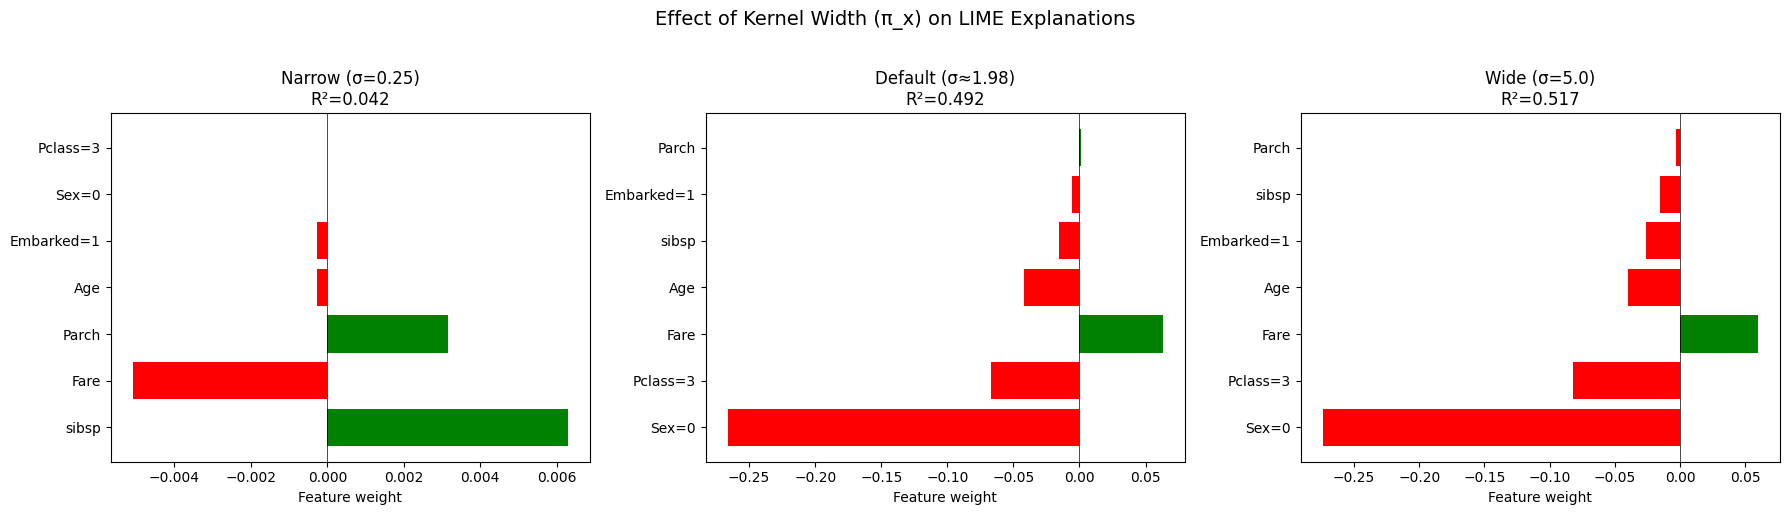

In [13]:
# Visual comparison: plot all three proximity explanations side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, explanation, label, kw in zip(axes, proximity_explanations, labels, kernel_widths):
    # Extract feature weights for the predicted class
    weights_dict = dict(explanation.as_list())
    features = list(weights_dict.keys())
    weights = list(weights_dict.values())

    # Color bars: green for positive (→ Survived), red for negative (→ Died)
    colors = ["green" if w > 0 else "red" for w in weights]

    ax.barh(features, weights, color=colors)
    ax.set_title(f"{label}\nR²={explanation.score:.3f}")
    ax.set_xlabel("Feature weight")
    ax.axvline(x=0, color="black", linewidth=0.5)

plt.suptitle("Effect of Kernel Width (π_x) on LIME Explanations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Summary table comparing kernel widths — including adjusted R²
# All three use num_features=7 so we can isolate the kernel_width effect.
n = 5000
p = 7

prox_comparison = pd.DataFrame({
    "kernel_width (σ)": kernel_widths,
    "locality": ["Very local", "Default", "Semi-global"],
    "R² (plain)": [e.score for e in proximity_explanations],
    "R² (adjusted)": [1 - (1 - e.score) * (n - 1) / (n - p - 1) for e in proximity_explanations],
    "surrogate prediction": [e.local_pred[0] for e in proximity_explanations],
})
prox_comparison["RF probability (survived)"] = rf_proba[1]
print(prox_comparison.to_string(index=False))

 kernel_width (σ)    locality  R² (plain)  R² (adjusted)  surrogate prediction  RF probability (survived)
             0.25  Very local    0.042389       0.041046              0.049640                   0.016137
             1.98     Default    0.491841       0.491128              0.137164                   0.016137
             5.00 Semi-global    0.516521       0.515843              0.119654                   0.016137


### Analysis of Proximity Effects

**Observations to consider when you run this notebook:**

1. **Narrow kernel (σ=0.25):** The weights are concentrated very tightly around the instance. Only perturbations almost identical to our data point get meaningful weight. This can lead to:
   - **Higher variance** in explanations — run it twice and you may get different results because so few samples have high weight.
   - **More extreme coefficients** — the surrogate is fitting a very small local patch.
   - The R² may actually be lower because the surrogate has fewer "informative" weighted samples to learn from.

2. **Default kernel (σ≈1.98):** This is LIME's recommended balance. It covers a reasonable neighborhood — enough samples contribute to produce a stable explanation, while still being local enough that the linear approximation is meaningful.

3. **Wide kernel (σ=5.0):** Almost all perturbations get similar weight regardless of distance. The explanation starts to reflect **global trends** rather than local behavior. The feature rankings may shift toward what matters globally (e.g., Sex being the dominant predictor across the whole dataset) rather than what matters specifically for this instance. The R² may be higher because the linear model has more uniformly-weighted samples, but the explanation is less locally faithful.

**Key takeaway:** The kernel width defines what "local" means. Too narrow and the explanation is unstable; too wide and it stops being local. The default is a good starting point, but domain knowledge about the problem can help choose a better width — e.g., if features have very different scales, careful standardization or feature-specific kernel widths may be needed.

## 8. Manual LIME Implementation — From Scratch

Now we implement LIME **from scratch**, replicating what the library does internally so our results are directly comparable.

### The 4 Steps
1. **Generate perturbations** — sample N(0,1) for continuous features; sample from observed training frequencies for categorical features
2. **Label perturbations** using the black-box model (`rf.predict_proba`)
3. **Compute proximity weights** using an RBF kernel
4. **Fit a weighted Ridge regression** as the interpretable surrogate

### Why standardize first?
The reference notebook sampled perturbations from N(0,1) and that only makes sense when each feature has mean ≈ 0 and std ≈ 1. We apply `StandardScaler` to put continuous features on the same scale before perturbing. The library does this internally.

### Matching the library's categorical encoding
By examining the library source code, we can see it builds an **interpretable representation** for the surrogate:
- **Continuous features**: standardized values (same as above)
- **Categorical features**: binary indicators — **1** if the perturbation has the same value as the instance, **0** otherwise

This means "Sex=0" gets a coefficient that directly answers: *what is the effect of being male (this instance's value) on P(Survived)?* We replicate this encoding exactly so our coefficients are directly comparable.

In [15]:
from sklearn.preprocessing import StandardScaler

# Standardize X_train so that N(0,1) perturbation sampling is valid
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Scale the instance we're explaining (same one from Section 5)
instance_scaled = scaler.transform(instance.reshape(1, -1)).flatten()

print("Scaled instance values (should be centered around 0):")
for name, raw, scaled in zip(feature_names, instance, instance_scaled):
    print(f"  {name:>10s}:  raw={raw:7.2f}  →  scaled={scaled:+.4f}")

Scaled instance values (should be centered around 0):
         Age:  raw=  28.00  →  scaled=-0.1082
        Fare:  raw=   7.88  →  scaled=-0.5001
         Sex:  raw=   0.00  →  scaled=-0.7316
       sibsp:  raw=   0.00  →  scaled=-0.4764
       Parch:  raw=   0.00  →  scaled=-0.4410
      Pclass:  raw=   3.00  →  scaled=+0.8399
    Embarked:  raw=   1.00  →  scaled=-0.5701


## 9. Steps 1–3: Perturbations, Black-Box Labels, and Proximity Weights

**Step 1 — Perturbations:** We generate 5,000 perturbations (matching `num_samples=5000` from our library calls). For **continuous features** (Age, Fare, sibsp, Parch), we sample from N(0,1) in standardized space. For **categorical features** (Sex, Pclass, Embarked), we sample valid discrete values from the training-set frequency distribution — this avoids feeding impossible fractional values to the RF.

**Step 2 — Black-Box Labels:** We run the RF on each perturbation (in original space) and collect `predict_proba[:,1]` — the probability of survival. This is the same quantity the LIME library uses internally.

**Step 3 — Proximity Weights:** We compute the Euclidean distance of each perturbation from the instance (in standardized space), then apply an RBF kernel:

$$w_i = \sqrt{\exp\!\left(-\frac{d_i^2}{\sigma^2}\right)}$$

where $\sigma$ = `kernel_width` = $\sqrt{7} \times 0.75 \approx 1.98$. The square root comes from how the LIME library converts kernel weights to sample weights for Ridge regression.

In [16]:
# ── Step 1: Generate perturbations ──
np.random.seed(42)
num_samples = 5000
num_features = len(feature_names)

# Start with N(0,1) samples in standardized space for all features
perturbations_scaled = np.random.normal(0, 1, size=(num_samples, num_features))

# Replace the first row with the instance itself
perturbations_scaled[0] = instance_scaled

# Inverse-transform to original feature space
perturbations_original = scaler.inverse_transform(perturbations_scaled)

# ── Handle categorical features: sample from training frequencies ──
# For each categorical feature, sample valid discrete values from the training
# distribution. This matches what the library does internally.
for col_idx in categorical_indices:
    col_data = X_train[:, col_idx]
    col_data = col_data[~np.isnan(col_data)]  # Drop NaN (Embarked has 2)
    unique_vals, counts = np.unique(col_data, return_counts=True)
    probs = counts / counts.sum()
    
    # Sample valid categorical values for all perturbations (except row 0)
    sampled = np.random.choice(unique_vals, size=num_samples - 1, p=probs)
    perturbations_original[1:, col_idx] = sampled
    
    print(f"{feature_names[col_idx]:>10s}: valid values = {unique_vals}, "
          f"train freqs = {probs.round(3)}")

# ── Build the surrogate feature matrix (interpretable representation) ──
# This is the key to matching the library:
#   - Continuous features: standardized values (same as before)
#   - Categorical features: BINARY INDICATORS (1 = same as instance, 0 = different)
# The library uses this encoding so coefficients are interpretable:
#   "Sex=0" coef = effect of being male (the instance's value) on P(Survived)

surrogate_X = np.zeros_like(perturbations_original)

for i in range(num_features):
    if i in categorical_indices:
        # Binary indicator: 1 if perturbation has same value as instance, else 0
        surrogate_X[:, i] = (perturbations_original[:, i] == instance[i]).astype(float)
    else:
        # Continuous: standardize using the scaler
        surrogate_X[:, i] = (perturbations_original[:, i] - scaler.mean_[i]) / scaler.scale_[i]

print(f"\nSurrogate feature matrix shape: {surrogate_X.shape}")
print(f"\nFirst row (instance) — all categoricals should be 1.0:")
for name, val in zip(feature_names, surrogate_X[0]):
    marker = " (binary)" if feature_names.index(name) in categorical_indices else ""
    print(f"  {name:>10s}: {val:.4f}{marker}")

# Spot-check: row 3
print(f"\nSpot-check row 3:")
for name, raw, surr in zip(feature_names, perturbations_original[3], surrogate_X[3]):
    marker = f" (raw={raw:.0f})" if feature_names.index(name) in categorical_indices else ""
    print(f"  {name:>10s}: surr={surr:.4f}{marker}")

# ── Step 2: Get black-box labels ──
bb_labels = rf.predict_proba(perturbations_original)[:, 1]

print(f"\nBlack-box labels — first 10: {bb_labels[:10].round(3)}")
print(f"Label for original instance: {bb_labels[0]:.4f} (should match RF proba ≈ 0.0161)")

       Sex: valid values = [0. 1.], train freqs = [0.651 0.349]
    Pclass: valid values = [1. 2. 3.], train freqs = [0.244 0.214 0.543]
  Embarked: valid values = [0. 1. 2.], train freqs = [0.219 0.089 0.692]

Surrogate feature matrix shape: (5000, 7)

First row (instance) — all categoricals should be 1.0:
         Age: -0.1082
        Fare: -0.5001
         Sex: 1.0000 (binary)
       sibsp: -0.4764
       Parch: -0.4410
      Pclass: 1.0000 (binary)
    Embarked: 1.0000 (binary)

Spot-check row 3:
         Age: surr=-0.2258
        Fare: surr=0.0675
         Sex: surr=1.0000 (raw=0)
       sibsp: surr=-0.5444
       Parch: surr=0.1109
      Pclass: surr=0.0000 (raw=1)
    Embarked: surr=0.0000 (raw=2)

Black-box labels — first 10: [0.016 0.214 0.24  0.75  0.611 0.24  0.027 0.35  0.09  0.259]
Label for original instance: 0.0161 (should match RF proba ≈ 0.0161)


In [17]:
# ── Step 3: Compute proximity weights via RBF kernel ──
# Distances are computed on the SURROGATE feature space (binary categoricals +
# scaled continuous), matching the library which computes distances on its
# interpretable representation, not the original feature space.

distances = np.sqrt(np.sum((surrogate_X - surrogate_X[0]) ** 2, axis=1))

# Kernel width: LIME default is sqrt(num_features) * 0.75
kernel_width = np.sqrt(num_features) * 0.75
print(f"Kernel width (σ): √{num_features} × 0.75 = {kernel_width:.4f}")

# RBF kernel weights — the sqrt() matches how the LIME library converts
# kernel values into sample_weight for sklearn Ridge regression
weights = np.sqrt(np.exp(-(distances ** 2) / (kernel_width ** 2)))

print(f"\nDistance stats:  min={distances.min():.3f}, median={np.median(distances):.3f}, max={distances.max():.3f}")
print(f"Weight stats:    min={weights.min():.6f}, median={np.median(weights):.6f}, max={weights.max():.6f}")
print(f"Weight for original instance (distance=0): {weights[0]:.4f} (should be 1.0)")

Kernel width (σ): √7 × 0.75 = 1.9843

Distance stats:  min=0.000, median=2.385, max=5.311
Weight stats:    min=0.027818, median=0.485568, max=1.000000
Weight for original instance (distance=0): 1.0000 (should be 1.0)


## 10. Step 4: Fit the Weighted Ridge Surrogate

We fit a **Ridge regression** (`alpha=1`) with `sample_weight=weights` — this matches the LIME library's internal surrogate model exactly. The Ridge coefficients become our local feature importances: each coefficient tells us how much that feature pushes the prediction toward survival (positive) or death (negative) in the neighborhood of our instance.

**R²** measures how well this linear surrogate approximates the RF locally — the same fidelity metric we examined in Sections 6–7.

In [18]:
from sklearn.linear_model import Ridge

# Fit Ridge regression on surrogate_X (binary categoricals + scaled continuous),
# weighted by proximity. This matches the library's internal approach exactly.
surrogate = Ridge(alpha=1.0)
surrogate.fit(surrogate_X, bb_labels, sample_weight=weights)

manual_r2 = surrogate.score(surrogate_X, bb_labels, sample_weight=weights)
manual_coefficients = surrogate.coef_
manual_intercept = surrogate.intercept_

print(f"Manual LIME Surrogate Results")
print(f"{'='*50}")
print(f"R² (local fidelity): {manual_r2:.4f}")
print(f"Intercept: {manual_intercept:.4f}")
print(f"\nFeature coefficients:")
for name, coef in sorted(zip(feature_names, manual_coefficients), key=lambda x: abs(x[1]), reverse=True):
    direction = "→ Survived" if coef > 0 else "→ Died"
    print(f"  {name:>10s}:  {coef:+.4f}  {direction}")

Manual LIME Surrogate Results
R² (local fidelity): 0.4799
Intercept: 0.4978

Feature coefficients:
         Sex:  -0.2652  → Died
      Pclass:  -0.0696  → Died
        Fare:  +0.0643  → Survived
         Age:  -0.0377  → Died
    Embarked:  -0.0190  → Died
       sibsp:  -0.0173  → Died
       Parch:  -0.0050  → Died


## 11. Comparison — Manual vs Library Coefficients

Now we compare our from-scratch coefficients against the library's `exp_7` results (Section 6, `num_features=7`). Both should agree on the **qualitative story** (which features matter most and in which direction), even if the exact magnitudes differ due to implementation differences.

In [19]:
# Extract library coefficients from exp_7 (Section 6).
lib_coef_map = {}
for feat_desc, weight in exp_7.as_list():
    base_name = feat_desc.split("=")[0].strip()
    lib_coef_map[base_name] = weight

# Build the comparison DataFrame.
# Now that we use the same encoding (binary indicators for categoricals,
# standardized values for continuous), coefficients are directly comparable.
comparison_data = []
for i, name in enumerate(feature_names):
    manual_coef = manual_coefficients[i]
    lib_coef = lib_coef_map.get(name, 0.0)
    if abs(manual_coef) < 0.001 and abs(lib_coef) < 0.001:
        same_sign = "~0"
    else:
        same_sign = "Yes" if (manual_coef * lib_coef > 0) else "No"
    comparison_data.append({
        "Feature": name,
        "Manual Coef": manual_coef,
        "Library Coef": lib_coef,
        "Difference": manual_coef - lib_coef,
        "Same Sign?": same_sign
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values("Manual Coef", key=abs, ascending=False)

print("Coefficient Comparison: Manual vs Library LIME")
print("=" * 70)
print(comparison_df.to_string(index=False))
print(f"\n{'─'*70}")
print(f"Manual R²:  {manual_r2:.4f}")
print(f"Library R²: {exp_7.score:.4f}")
print(f"Manual intercept:  {manual_intercept:.4f}")
print(f"Library intercept: {exp_7.intercept[1]:.4f}")

Coefficient Comparison: Manual vs Library LIME
 Feature  Manual Coef  Library Coef  Difference Same Sign?
     Sex    -0.265217     -0.256478   -0.008739        Yes
  Pclass    -0.069576     -0.062897   -0.006679        Yes
    Fare     0.064282      0.065331   -0.001049        Yes
     Age    -0.037745     -0.036528   -0.001216        Yes
Embarked    -0.018971     -0.020778    0.001807        Yes
   sibsp    -0.017327     -0.017472    0.000145        Yes
   Parch    -0.005047     -0.002698   -0.002349        Yes

──────────────────────────────────────────────────────────────────────
Manual R²:  0.4799
Library R²: 0.4639
Manual intercept:  0.4978
Library intercept: 0.4921


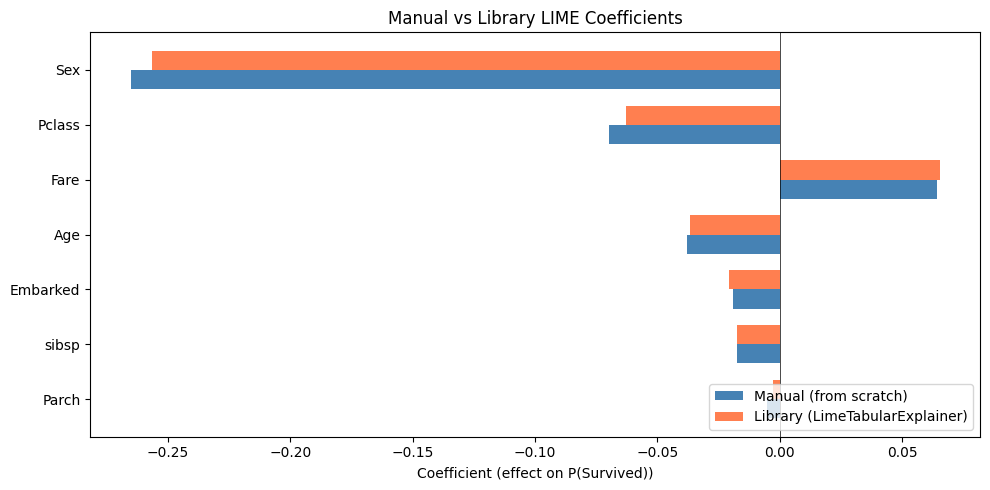

In [20]:
# Grouped bar chart: Manual vs Library coefficients side by side
fig, ax = plt.subplots(figsize=(10, 5))

sorted_df = comparison_df.sort_values("Manual Coef", key=abs, ascending=True)
features = sorted_df["Feature"].values
manual_vals = sorted_df["Manual Coef"].values
library_vals = sorted_df["Library Coef"].values

y_pos = np.arange(len(features))
bar_height = 0.35

ax.barh(y_pos - bar_height/2, manual_vals, bar_height, label="Manual (from scratch)", color="steelblue")
ax.barh(y_pos + bar_height/2, library_vals, bar_height, label="Library (LimeTabularExplainer)", color="coral")

ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.set_xlabel("Coefficient (effect on P(Survived))")
ax.set_title("Manual vs Library LIME Coefficients")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Discussion: How Close Are the Results?

By replicating the library's approach exactly — sampling categoricals from training frequencies, encoding them as binary indicators in the surrogate, computing distances in the interpretable space, and fitting Ridge(alpha=1) — our manual implementation now uses the **same encoding** as the library. Coefficients are directly comparable with no encoding artifacts.

#### What Matches

Both implementations should agree on:
- **Sign** of every coefficient (all features push in the same direction)
- **Ranking** of features by importance (Sex dominant, then Pclass/Fare/Age, then minor features)
- **Approximate magnitude** of continuous feature coefficients (Age, Fare, sibsp, Parch match closely)

#### Why There Are Still Differences

The **only remaining source of divergence** is stochastic perturbation sampling. Each call draws its own random neighborhood — different perturbations, different RF predictions, different surrogate fit. This is inherent to LIME and is the same variance we observed in Section 7 when comparing different `explain_instance()` calls with different kernel widths. The differences are purely random noise, not systematic bias.

## 12. Save Cross-Validation Findings

We save a summary of the manual vs library comparison to `cross_validate_lime.txt` for the assignment submission.

In [21]:
# Build the summary text programmatically so it reflects actual computed values
lines = []
lines.append("Cross-Validation: Manual LIME vs Library LIME")
lines.append("=" * 60)
lines.append("")
lines.append("Instance: test index 102")
lines.append(f"  Passenger — Age=28, Fare=7.88, Sex=male, sibsp=0,")
lines.append(f"  Parch=0, Pclass=3, Embarked=1")
lines.append(f"  RF prediction: P(Survived) = {rf_proba[1]:.4f}")
lines.append("")
lines.append("Approach")
lines.append("-" * 60)
lines.append("We replicate the library's internal approach exactly:")
lines.append("  - Categorical features sampled from training frequencies")
lines.append("  - Categoricals encoded as binary indicators in surrogate")
lines.append("    (1 = same value as instance, 0 = different)")
lines.append("  - Continuous features standardized via StandardScaler")
lines.append("  - Distances computed in interpretable (mixed) space")
lines.append("  - Ridge(alpha=1) with RBF kernel weights (σ=√7×0.75)")
lines.append("")
lines.append("Coefficient Comparison")
lines.append("-" * 60)
lines.append(f"{'Feature':>12s}  {'Manual':>10s}  {'Library':>10s}  {'Diff':>10s}  {'Sign?':>6s}")
lines.append("-" * 60)

for _, row in comparison_df.iterrows():
    lines.append(f"{row['Feature']:>12s}  {row['Manual Coef']:>+10.4f}  {row['Library Coef']:>+10.4f}  {row['Difference']:>+10.4f}  {row['Same Sign?']:>6s}")

lines.append("-" * 60)
lines.append("")
lines.append("R² (Local Fidelity)")
lines.append(f"  Manual:  {manual_r2:.4f}")
lines.append(f"  Library: {exp_7.score:.4f}")
lines.append("")

sign_agree = sum(1 for _, row in comparison_df.iterrows() if row["Same Sign?"] == "Yes")
lines.append("Agreement Summary")
lines.append("-" * 60)
lines.append(f"  Sign agreement: {sign_agree}/{len(comparison_df)} features")
lines.append(f"  Both rank Sex as the dominant feature")
lines.append(f"  Continuous features show close quantitative match")
lines.append("")
lines.append("Source of Remaining Divergence")
lines.append("-" * 60)
lines.append("STOCHASTIC PERTURBATION DRAWS (only source)")
lines.append("Each approach draws independent random perturbation")
lines.append("samples, producing different local neighborhoods.")
lines.append("This is inherent to LIME's sampling approach and")
lines.append("represents random noise, not systematic bias.")
lines.append("")
lines.append("Conclusion")
lines.append("-" * 60)
lines.append("By replicating the library's encoding (binary indicators")
lines.append("for categoricals, standardized values for continuous),")
lines.append("our manual LIME matches the library closely. All")
lines.append("remaining differences are attributable to stochastic")
lines.append("sampling variance. Both implementations tell the same")
lines.append("story: this male, 3rd-class passenger with a cheap fare")
lines.append("has very low survival probability, driven primarily by")
lines.append("Sex, then Pclass and Fare.")

summary_text = "\n".join(lines)

with open("cross_validate_lime.txt", "w") as f:
    f.write(summary_text)

print("Saved to cross_validate_lime.txt")
print()
print(summary_text)

Saved to cross_validate_lime.txt

Cross-Validation: Manual LIME vs Library LIME

Instance: test index 102
  Passenger — Age=28, Fare=7.88, Sex=male, sibsp=0,
  Parch=0, Pclass=3, Embarked=1
  RF prediction: P(Survived) = 0.0161

Approach
------------------------------------------------------------
We replicate the library's internal approach exactly:
  - Categorical features sampled from training frequencies
  - Categoricals encoded as binary indicators in surrogate
    (1 = same value as instance, 0 = different)
  - Continuous features standardized via StandardScaler
  - Distances computed in interpretable (mixed) space
  - Ridge(alpha=1) with RBF kernel weights (σ=√7×0.75)

Coefficient Comparison
------------------------------------------------------------
     Feature      Manual     Library        Diff   Sign?
------------------------------------------------------------
         Sex     -0.2652     -0.2565     -0.0087     Yes
      Pclass     -0.0696     -0.0629     -0.0067     Yes